In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
!pip install tensorflowjs

import tensorflowjs as tfjs
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make NumPy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

2026-05-07 06:30:13.827363: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778135413.843243    2761 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778135413.847636    2761 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778135413.860033    2761 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778135413.860062    2761 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778135413.860064    2761 computation_placer.cc:177] computation placer alr

2.19.0
/kaggle/input/datasets/algozee/teenager-menthal-healy/Teen_Mental_Health_Dataset.csv


In [2]:
file = pd.read_csv("/dataset/Teen_Mental_Health_Dataset.csv")
file.describe()
df = file.copy()
df.tail()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0
1199,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,7,3,0


In [3]:
map_cat = {'low':0, 'medium':1, 'high':2}
df["social_interaction_level"] = df["social_interaction_level"].map(map_cat)

df = pd.get_dummies(df, columns=['gender', 'platform_usage'])
df.tail()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,gender_female,gender_male,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok
1195,18,6.8,6.6,2.0,2.76,1.0,0,3,4,4,0,True,False,False,True,False
1196,16,2.3,8.0,1.9,2.12,0.4,2,7,4,4,0,False,True,True,False,False
1197,14,1.7,8.7,0.7,3.98,0.8,2,1,1,1,0,True,False,True,False,False
1198,15,3.9,8.5,2.1,3.19,0.6,2,7,9,9,0,False,True,True,False,False
1199,16,4.7,6.5,1.0,2.91,0.9,1,5,7,3,0,True,False,False,False,True


In [4]:
x = df.drop('depression_label', axis=1).astype(np.float32)
y = df['depression_label'].astype(np.float32)
print(x.tail())
print(y.tail())

       age  daily_social_media_hours  sleep_hours  screen_time_before_sleep  \
1195  18.0                       6.8          6.6                       2.0   
1196  16.0                       2.3          8.0                       1.9   
1197  14.0                       1.7          8.7                       0.7   
1198  15.0                       3.9          8.5                       2.1   
1199  16.0                       4.7          6.5                       1.0   

      academic_performance  physical_activity  social_interaction_level  \
1195                  2.76                1.0                       0.0   
1196                  2.12                0.4                       2.0   
1197                  3.98                0.8                       2.0   
1198                  3.19                0.6                       2.0   
1199                  2.91                0.9                       1.0   

      stress_level  anxiety_level  addiction_level  gender_female  \
1195 

In [5]:
np.random.seed(42)
shuffle_index = np.random.permutation(len(x))
split_index = int(len(x) * 0.8)

train_indices = shuffle_index[:split_index]
test_indices = shuffle_index[split_index:]

# Slice the dataframes
x_train, x_test = x.iloc[train_indices], x.iloc[test_indices]
y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

In [6]:
train_mean = x_train.mean(axis=0)
train_std = x_train.std(axis=0)

# Replace any zero standard deviations with a tiny number to prevent divide-by-zero errors
train_std = np.where(train_std == 0, 1e-7, train_std)

x_train = (x_train-train_mean)/train_std
x_test = (x_test-train_mean)/train_std

x_train.tail()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_female,gender_male,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok
978,0.031537,0.053760,-0.781856,-0.609447,1.329547,-0.880395,0.069903,-0.844630,0.834945,0.866972,-0.968718,0.968718,1.420132,-0.713375,-0.703430
1002,-0.464781,0.251307,-0.086293,-0.331505,-0.558848,0.154730,1.312631,0.194027,-1.259690,-0.195530,1.031216,-1.031216,-0.703430,-0.713375,1.420132
509,0.527855,-1.131523,0.052819,1.753065,-0.870694,-1.397958,0.069903,-0.152192,0.834945,-0.549697,1.031216,-1.031216,-0.703430,-0.713375,1.420132
111,0.527855,0.350080,-0.294962,-1.582246,0.134140,-0.707875,0.069903,0.194027,-1.259690,1.221140,1.031216,-1.031216,1.420132,-0.713375,-0.703430
226,-0.961100,-0.341334,-0.781856,-1.026361,-1.234513,0.327250,-1.172825,1.232683,-0.910584,-1.612200,-0.968718,0.968718,-0.703430,1.400328,-0.703430


In [7]:
print([x_train.shape[1],])
model = tf.keras.Sequential([
    tf.keras.layers.Input([x_train.shape[1],]),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Outputs probability
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

[15]


2026-05-07 06:30:19.633520: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1, # Uses 10% of training data to validate during training
    verbose=1
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6866 - loss: 0.5831 - val_accuracy: 0.9896 - val_loss: 0.1922
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9868 - loss: 0.1753 - val_accuracy: 1.0000 - val_loss: 0.0730
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9789 - loss: 0.1291 - val_accuracy: 1.0000 - val_loss: 0.0413
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9730 - loss: 0.1199 - val_accuracy: 1.0000 - val_loss: 0.0289
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9780 - loss: 0.1028 - val_accuracy: 1.0000 - val_loss: 0.0237
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9818 - loss: 0.0803 - val_accuracy: 1.0000 - val_loss: 0.0225
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9698 - loss: 0.0993 - val_accuracy: 1.0000 - val_loss: 0.0205
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9745 - loss: 0.0756 - val_accuracy: 1.0000 - val_loss:

In [9]:
probabilities = model.predict(x_test)
print(f"Sample prediction probabilities: \n{probabilities[:10]}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Sample prediction probabilities: 
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


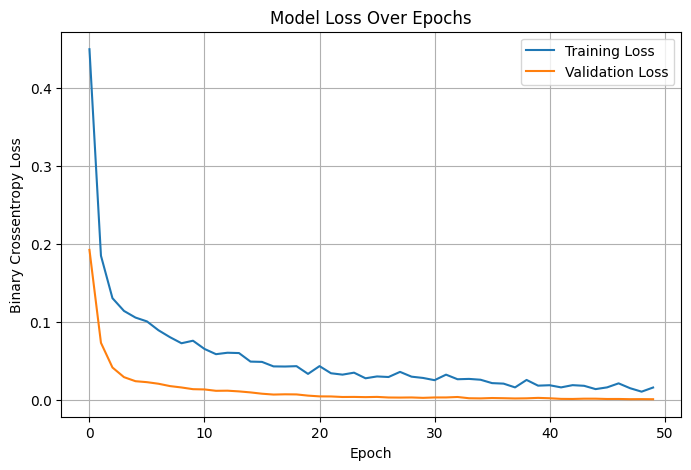

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# 1. Save the model in the modern Keras 3 format
model.save("depression_model.keras")

# 2. Convert the model with explicit input AND output formats
!tensorflowjs_converter \
    --input_format=keras_keras \
    --output_format=tfjs_layers_model \
    depression_model.keras \
    tfjs_model

# 3. Zip the resulting folder for easy downloading
!zip -r tfjs_model.zip tfjs_model/

print("Conversion and zipping complete! You can now download tfjs_model.zip from the Kaggle output panel.")


2026-05-07 06:35:16.067421: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778135716.083488    4063 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778135716.089168    4063 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778135716.102475    4063 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778135716.102525    4063 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778135716.102529    4063 computation_placer.cc:177] computation placer alr